In [262]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
import numpy as np
from tqdm import tqdm
from stsci.skypac import pamutils
from astropy.wcs.utils import proj_plane_pixel_scales
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import AutoMinorLocator

from astroquery.mast import Observations
import os
import glob
import shutil


import matplotlib.pylab as pylab
plt.style.use("science")
params = {
         'axes.labelsize': 15,
         'axes.titlesize': 25,
         'ytick.labelsize' :12,
         'xtick.labelsize' :12,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 1,
         'xtick.minor.width': 1,
         'ytick.color': "w",
         'xtick.color': "w",
         'axes.labelcolor': "k",
         'ytick.labelcolor' : "k",
         'xtick.labelcolor' : "k",
         }
pylab.rcParams.update(params)

def draw_scale_and_compass(ax, cutout, wcs, rotation=0, scale=1, x0=0.1, y0=0.1, compass_size=0.1, arrow_size=0.001, color="k", lw=2, textpad=5, fontsize=15):
    hdr = wcs.to_header()
    pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs) # in degrees /pixels
    pixel_scale = np.mean([pixel_scale_x, pixel_scale_y]) # for drawing arrows
    M, N = cutout.shape
    
    # nice doc here http://montage.ipac.caltech.edu/docs/headers.html
    # Remember that PC maps pixels to world, so it include a mirror flip of the j coordinate (East-West)
    pc_matrix = wcs.pixel_scale_matrix
    north = np.array([1, 0])
    east = np.array([0, -1]) # accounts for the mirror flip of that coordinate to stay in pixel space
    # Using these prints, the angle of rotation should be printed has the same (+180 undo the mirror flip)
    # print(np.arctan2(pc_matrix[1, 0], pc_matrix[0, 0]) * 180 / np.pi - 90)
    # print(np.arctan2(-pc_matrix[0, 1], pc_matrix[1, 1]) * 180 / np.pi - 90 + 180)
    # Now rotate PC matrix onto our projected coordinate system. This will be useful when images are rotated by 90 degrees or 180 etc. 
    assert rotation % 90 == 0, "Rotation should only be used for images flipped by 90 or 180 degrees"
    theta = rotation * np.pi / 180 / 2 # divide by two to apply this to the PC matrix
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    pc_matrix = R @ pc_matrix @ R.T
    
    # North arrow 
    ndx = (pc_matrix @ north)[0] * compass_size * N / pixel_scale # apply minus sign to recover the orientation of the image
    ndy = (pc_matrix @ north)[1] * compass_size * N / pixel_scale
    # East arrow
    edx = (pc_matrix @ east)[0] * compass_size * N / pixel_scale
    edy = (pc_matrix @ east)[1] * compass_size * N / pixel_scale
    # some convenient padding solutions
    nrx = abs(ndx) / np.sqrt(ndx**2 + ndy**2) 
    nry = abs(ndy) / np.sqrt(ndx**2 + ndy**2)
    erx = edx / np.sqrt(edx**2 + edy**2)
    ery = -edy / np.sqrt(edx**2 + edy**2)
    # Orientation of the letters N and E
    angle = (np.arctan2(np.abs(ndy), ndx) - np.pi / 2) * 180 / np.pi
    
    # Scale bar
    ax.plot([x0*N, x0*N + scale/pixel_scale_y/3600], [y0*M, y0*M], linewidth=lw, color=color)
    ax.text(x0*N + scale/pixel_scale_x/2/3600, y0*M+textpad/2, f"{abs(scale)}''", fontsize=fontsize, color=color, ha='center', weight='bold')

    # North arrow, on the bottom right corner, pointing up
    ax.arrow(x=(1 - x0)*N, y=y0*M, dx=ndx, dy=ndy, head_width=abs(arrow_size)*N, head_length=abs(arrow_size)*N, fc=color, ec=color, linewidth=lw)
    ax.text((1 - x0)*N+ndx+textpad*nrx, y0*M+ndy+textpad*nry, "N", color=color, fontsize=fontsize, ha='center', rotation=angle, weight='bold')
    
    # East arrow, on the bottom right corner, pointing left
    ax.arrow(x=(1 - x0)*N, y=y0*M, dx=edx, dy=edy, head_width=abs(arrow_size)*N, head_length=abs(arrow_size)*N, fc=color, ec=color, linewidth=lw)
    ax.text((1 - x0)*N+edx+4*textpad*erx/3, y0*M+edy+4*textpad*ery/3, "E", color=color, fontsize=fontsize, ha='center', rotation=angle, weight='bold')
    return ax

# Download the targets

More specifically, we want to download the flat fields, which are *flt* and *flc* file (*flc* for CTE corrected flat fields), and the drizzled images (*drz*) for analysis. 

In [2]:
# A useful list of criteria is provided by the following line
Observations.get_metadata("observations")

Column Name,Column Label,Data Type,Units,Description,Examples/Valid Values
str21,str25,str7,str10,str72,str116
intentType,Observation Type,string,,Whether observation is for science or calibration.,"Valid values: science, calibration"
obs_collection,Mission,string,,Collection,"E.g. SWIFT, PS1, HST, IUE"
provenance_name,Provenance Name,string,,"Provenance name, or source of data","E.g. TASOC, CALSTIS, PS1"
instrument_name,Instrument,string,,Instrument Name,"E.g. WFPC2/WFC, UVOT, STIS/CCD"
project,Project,string,,Processing project,"E.g. HST, HLA, EUVE, hlsp_legus"
filters,Filters,string,,Instrument filters,"F469N, NUV, FUV, LOW DISP, MIRROR"
wavelength_region,Waveband,string,,Energy Band,"EUV, XRAY, OPTICAL"
target_name,Target Name,string,,Target Name,Ex. COMET-67P-CHURYUMOV-GER-UPDATE
target_classification,Target Classification,string,,Type of target,Ex. COMET;COMET BEING ORBITED BY THE ROSETTA SPACECRAFT;SOLAR SYSTEM


In [3]:
# Query the object
obs_table = Observations.query_criteria(proposal_id="10092", target_name="COSMOS45-05", filters="F814W", project="HST")
obs_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str3,str6,str7,str3,str5,str7,str11,str29,str9,float64,float64,str5,str21,int64,float64,float64,float64,float64,float64,str30,float64,str5,str2,int64,str398,str34,str35,str6,bool,float64,str8,str9
science,HST,CALACS,ACS/WFC,HST,F814W,Optical,COSMOS45-05,CLUSTER OF GALAXIES;BLANK SKY,j8xiay010,149.4660889478,2.482802426862,image,"Scoville, Nicholas Z.",3,53457.27502523148,53457.33820810185,2028.0,708.0,959.0,The COSMOS 2-Degree ACS Survey,53822.63427075,10092,GO,--,POLYGON 149.47208551 2.50994654 149.47040208986544 2.5101763543031357 149.47040757 2.51020279 149.44202671 2.5140769 149.44201192922912 2.5140055913370523 149.44116992 2.51412052 149.42965056 2.45854388 149.43133394890893 2.4583141130843158 149.43132846 2.45828763 149.45970816 2.45441377 149.45972294135595 2.4544850801064695 149.46056491 2.45437014 149.47208551 2.50994654 149.47208551 2.50994654,mast:HST/product/j8xiay010_drz.jpg,mast:HST/product/j8xiay010_drz.fits,PUBLIC,False,nan,24822020,220459279


In [4]:
# Get a list of files associated with our target
Observations.get_product_list(obs_table[0])[:5]

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level
str8,str3,str5,str35,str64,str1,str67,str9,str28,str11,str1,str7,str20,str5,str50,int64,str8,str6,int64
26367052,HST,image,hst_10092_ay_acs_wfc_f814w_j8xiay,HAP trailer file,D,mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiay_trl.txt,AUXILIARY,--,TRL,--,HAP-SVM,DrizzlePac 3.5.1,10092,hst_10092_ay_acs_wfc_f814w_j8xiay_trl.txt,29756,24822020,PUBLIC,3
26367052,HST,image,hst_10092_ay_acs_wfc_f814w_j8xiay,Preview-Full,D,mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiay_drc.jpg,PREVIEW,--,--,--,HAP-SVM,DrizzlePac 3.5.1,10092,hst_10092_ay_acs_wfc_f814w_j8xiay_drc.jpg,5326503,24822020,PUBLIC,3
26367052,HST,image,hst_10092_ay_acs_wfc_f814w_j8xiay,HAP fits science image,D,mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiay_drc.fits,SCIENCE,--,DRC,--,HAP-SVM,DrizzlePac 3.5.1,10092,hst_10092_ay_acs_wfc_f814w_j8xiay_drc.fits,300813120,24822020,PUBLIC,3
26367052,HST,image,hst_10092_ay_acs_wfc_f814w_j8xiay,HAP source catalog,D,mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiay_point-cat.ecsv,SCIENCE,--,POINT-CAT,--,HAP-SVM,DrizzlePac 3.5.1,10092,hst_10092_ay_acs_wfc_f814w_j8xiay_point-cat.ecsv,79133,24822020,PUBLIC,3
26367052,HST,image,hst_10092_ay_acs_wfc_f814w_j8xiay,HAP source catalog,D,mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiay_segment-cat.ecsv,SCIENCE,--,SEGMENT-CAT,--,HAP-SVM,DrizzlePac 3.5.1,10092,hst_10092_ay_acs_wfc_f814w_j8xiay_segment-cat.ecsv,482882,24822020,PUBLIC,3


In [5]:
# We only focus on the on the files with an extension of interest
data_products = Observations.get_product_list(obs_table[0])
extensions = ["raw.fits", "flt.fits", "flc.fits", "drz.fits"]

selection = []
for i, filename in enumerate(data_products["dataURI"]):
    for ext in extensions:
        if ext in filename:
            selection.append(i)
            
data_products_of_interest = data_products[selection]
data_products_of_interest["dataURI"]

mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiaybh_flc.fits
mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiaybk_flc.fits
mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiaybn_flc.fits
mast:HST/product/hst_10092_ay_acs_wfc_f814w_j8xiayby_flc.fits
mast:HST/product/j8xiay010_drz.fits
mast:HST/product/j8xiaybhq_flc.fits
mast:HST/product/j8xiaybhq_flt.fits
mast:HST/product/j8xiaybhq_raw.fits
mast:HST/product/j8xiaybkq_flc.fits
mast:HST/product/j8xiaybkq_flt.fits
mast:HST/product/j8xiaybkq_raw.fits


In [6]:
# We will omit the first 4, and download the rest
data_products_of_interest = data_products_of_interest[4:]
data_products_of_interest["dataURI"]

mast:HST/product/j8xiay010_drz.fits
mast:HST/product/j8xiaybhq_flc.fits
mast:HST/product/j8xiaybhq_flt.fits
mast:HST/product/j8xiaybhq_raw.fits
mast:HST/product/j8xiaybkq_flc.fits
mast:HST/product/j8xiaybkq_flt.fits
mast:HST/product/j8xiaybkq_raw.fits
mast:HST/product/j8xiaybnq_flc.fits
mast:HST/product/j8xiaybnq_flt.fits
mast:HST/product/j8xiaybnq_raw.fits
mast:HST/product/j8xiaybyq_flc.fits


In [7]:
data_dir = "../data/COSMOS45-05/"
if not os.path.isdir(data_dir):
    os.mkdir(data_dir)
# This last line produce a shell script with curl commands ready to download our query
Observations.download_products(data_products_of_interest, download_dir=data_dir, curl_flag=True) 

Local Path,Status,Message
str50,str8,object
../data/COSMOS45-05/mastDownload_20230713234225.sh,COMPLETE,None


In [8]:
# Finally, move a bit the files to the root level of the data dir so they are easier to manipulate
files = glob.glob(data_dir + "*/HST/*/*.fits")
for f in files:
    try:
        shutil.move(f, data_dir)
    except:
        continue

# Science cutouts

In [9]:
data_dir = "../data/COSMOS45-05/"
drz_path = glob.glob(data_dir + "*drz.fits")[0]
flc_paths = glob.glob(data_dir + "*flc.fits") # in principle, we will only use flc, since they hace the additional CTE correction
flt_paths = glob.glob(data_dir + "*flt.fits")

## Specify the coordinates of our targets

In [10]:
coord1 = SkyCoord("9:57:56.5294", "2:27:37.963", unit=(u.hourangle, u.deg))
coord2 = SkyCoord("9:57:46.8867", "2:28:22.735", unit=(u.hourangle, u.deg))
coord3 = SkyCoord("9:57:49.1102", "2:28:19.430", unit=(u.hourangle, u.deg))

## Make cutouts around our targets

In [11]:
size = 64 * u.pixel
drz_data = fits.open(drz_path)
wcs = WCS(drz_data["sci"].header)
cutout1 = Cutout2D(drz_data["sci"].data, coord1, size, wcs=wcs)
cutout2 = Cutout2D(drz_data["sci"].data, coord2, size, wcs=wcs)
cutout3 = Cutout2D(drz_data["sci"].data, coord3, size, wcs=wcs)

In [337]:
data[1].header

XTENSION= 'IMAGE   '           / Image extension                                
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                   64                                                  
NAXIS2  =                   64                                                  
PCOUNT  =                    0 / number of parameters                           
GCOUNT  =                    1 / number of groups                               
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                900.0 / Pixel coordinate of reference point            
CRPIX2  =                625.0 / Pixel coordinate of reference point            
PC1_1   =  2.4116239374217E-06 / Coordinate transformation matrix element       
PC1_2   =  1.3677913018891E-05 / Coordinate transformation matrix element       
PC2_1   =  1.3677913018891E-

In [12]:
# Notice the convention choses the center as the central point of the lower left corner n the middle
cutout1.center_cutout

(31.5, 31.5)

In [330]:
cutout1.wcs.pixel_scale_matrix

array([[ 2.41162394e-06,  1.36779130e-05],
       [ 1.36779130e-05, -2.41162394e-06]])

In [13]:
# read off pixel scale in arcseconds
proj_plane_pixel_scales(wcs) * 3600

array([0.05, 0.05])

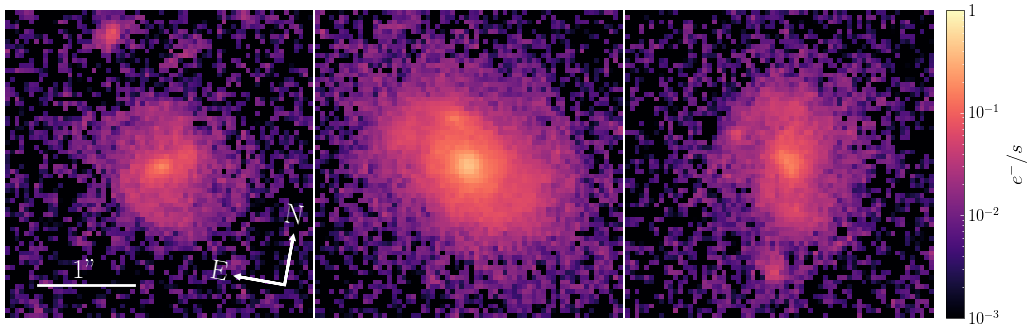

In [318]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
cutouts = [cutout1, cutout2, cutout3]
print_grid = True
for i, ax in enumerate(axs):
    im = ax.imshow(cutouts[i].data, cmap="magma", norm=plt.cm.colors.LogNorm(vmax=1, vmin=1e-3, clip=True), origin="lower")
    ax.axis("off")
    if i == 0:
        draw_scale_and_compass(ax, cutouts[i].data, cutouts[i].wcs, rotation=0, scale=1, x0=0.1, y0=0.1, compass_size=0.15, arrow_size=0.01, color="w", lw=2, textpad=3, fontsize=20)
    
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.91, 0.11, 0.015, 0.77])
cax = fig.colorbar(im, cax=cbar_ax, orientation='vertical', label=r"$e^-/s$")
cax.set_ticks([1e-3, 1e-2, 1e-1, 1], labels=[r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", "1"])
plt.subplots_adjust(hspace=0, wspace=0)

## Make same cutouts in flat field images

In [15]:
# Save the header, only way to save the distortion papers correctly
headers1_flc = []
headers2_flc = []
headers3_flc = []

cutouts1_flc = []
cutouts2_flc = []
cutouts3_flc = []
exptimes = []


for p in flc_paths:
    data = fits.open(p)
    exptimes.append(data[0].header["EXPTIME"])
    wcs = WCS(data[4].header, data) # data must included when distortions are present in the WCS
    cutout = Cutout2D(data[4].data, coord1, size, wcs=wcs)
    cutouts1_flc.append(cutout)
    headers1_flc.append(data[4].header)
    
    wcs = WCS(data[1].header, data)
    cutout = Cutout2D(data[1].data, coord2, size, wcs=wcs)
    cutouts2_flc.append(cutout)
    headers2_flc.append(data[1].header)
    
    cutout = Cutout2D(data[1].data, coord3, size, wcs=wcs)
    cutouts3_flc.append(cutout)
    headers3_flc.append(data[1].header)

exptimes

[507.0, 507.0, 507.0, 507.0]

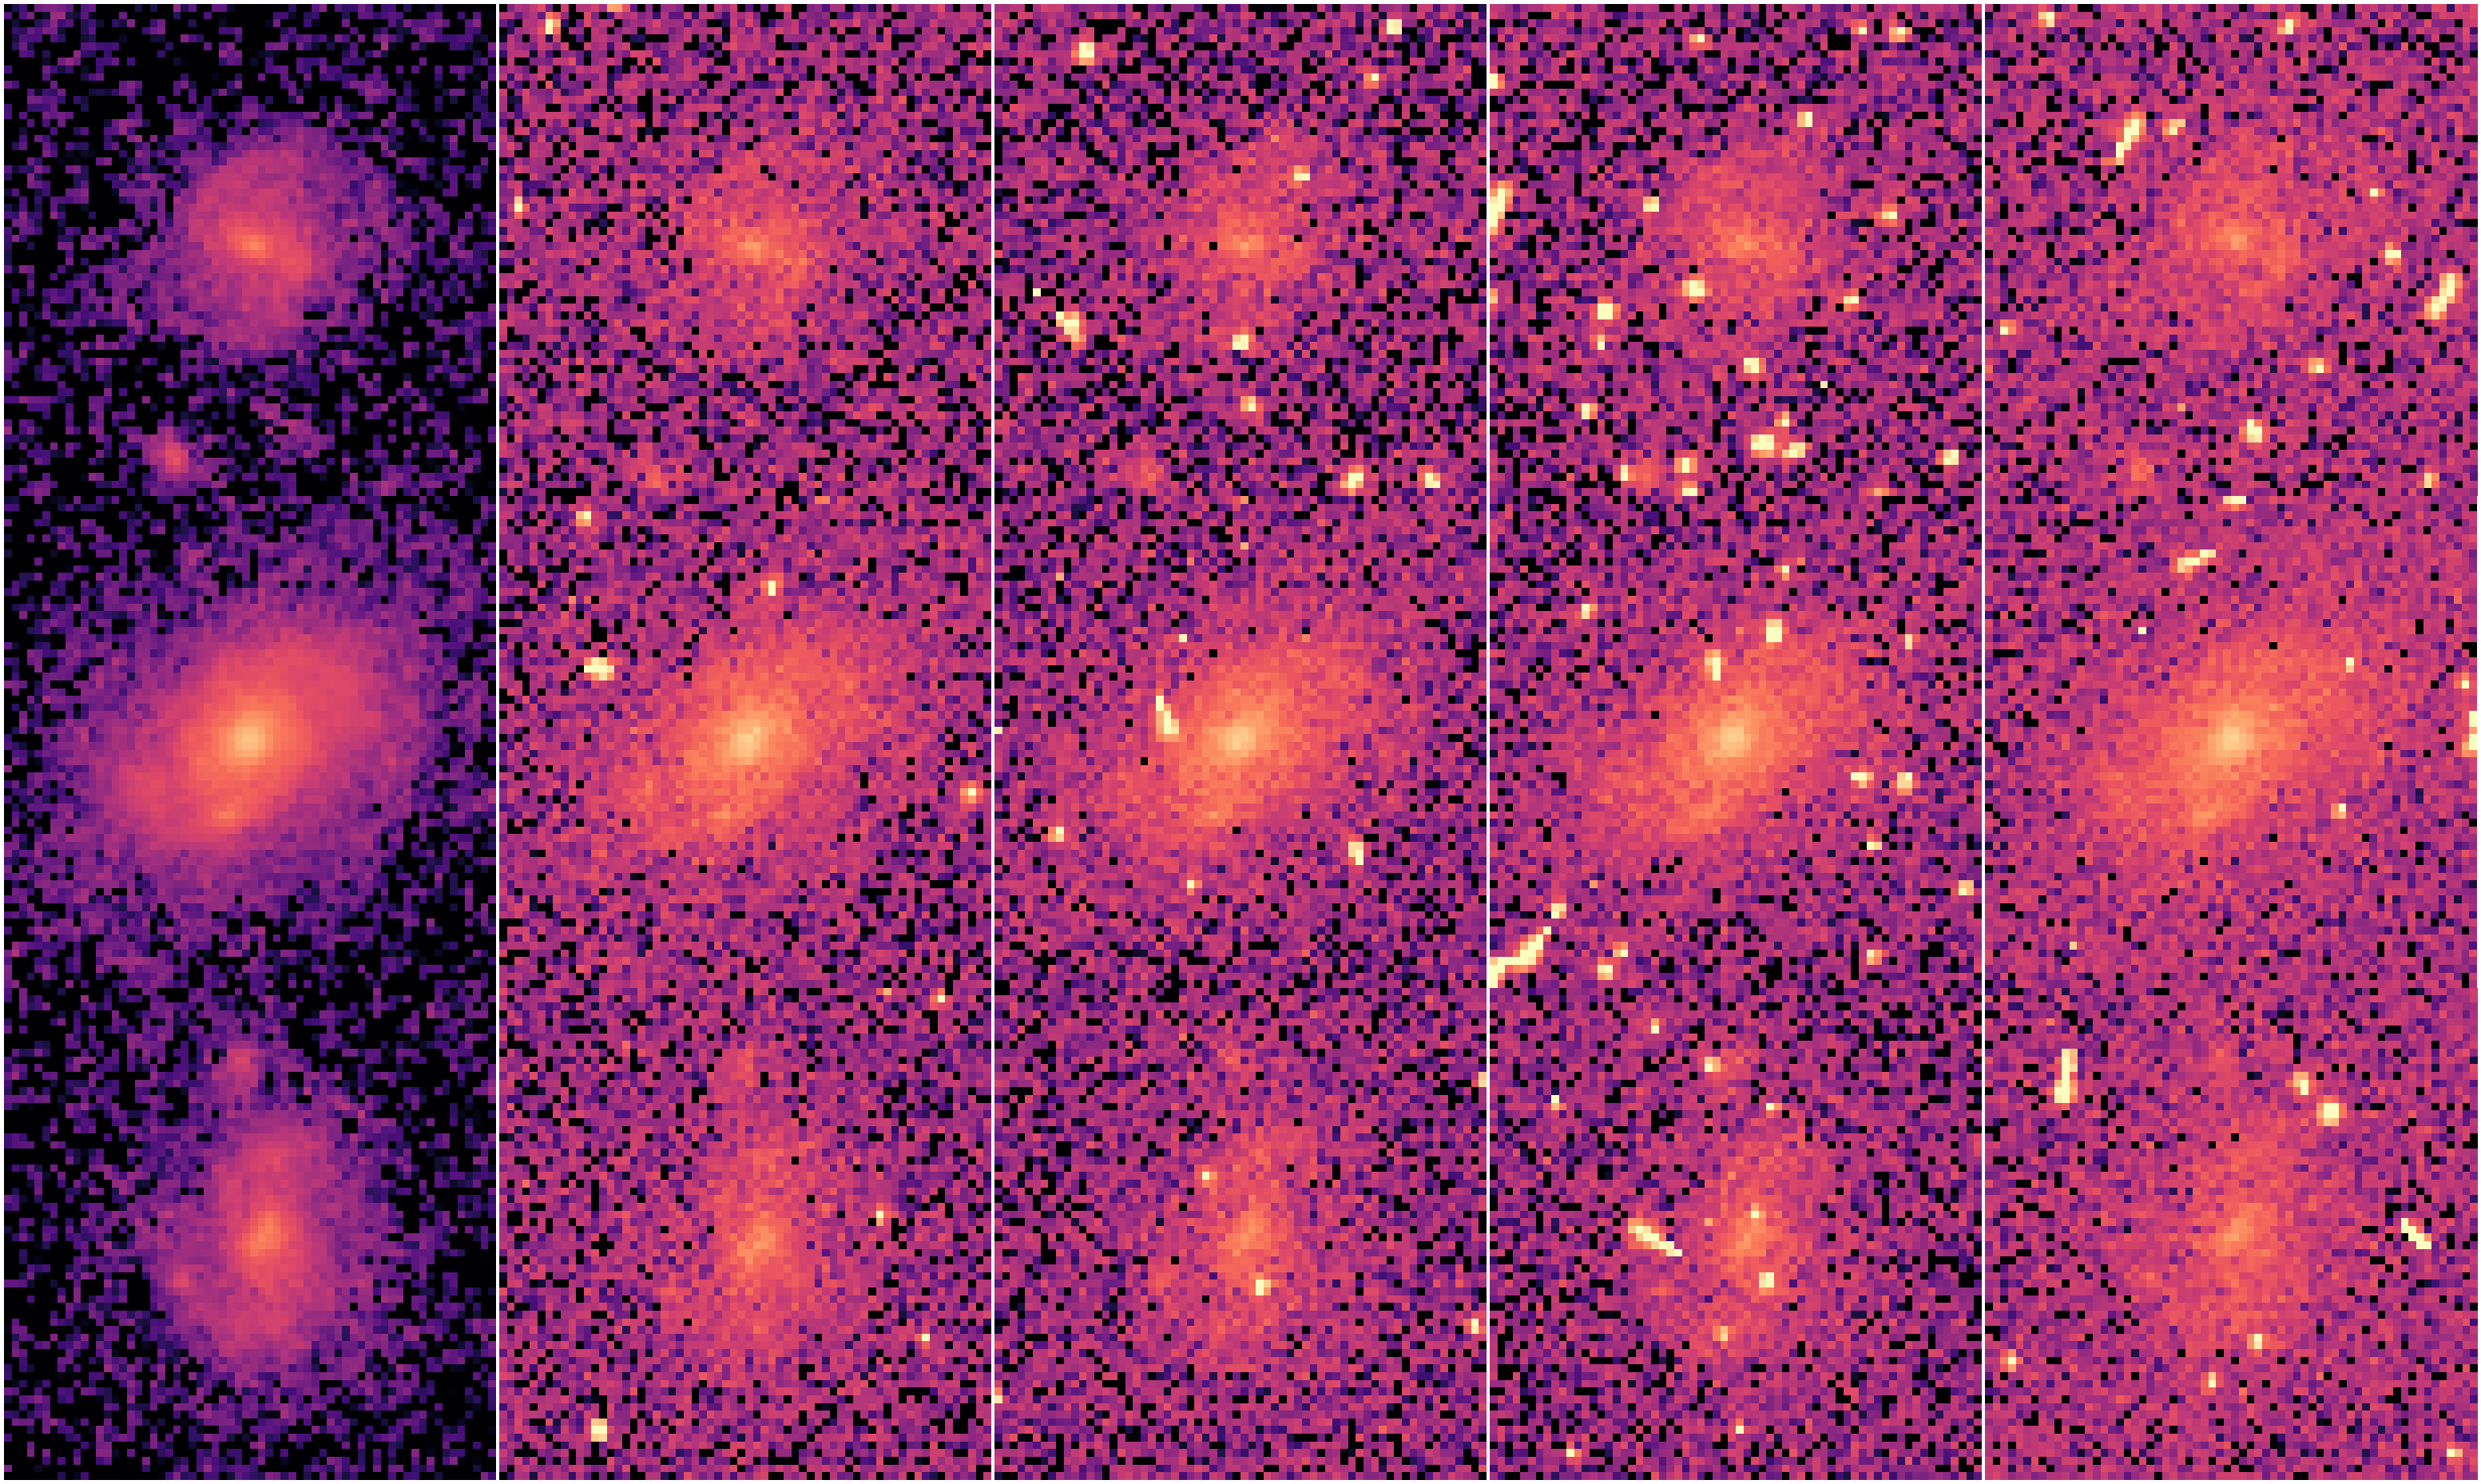

In [16]:
fig, axs = plt.subplots(3, 5, figsize=(40, 3*8))

vmin1 = 1e-3
vmin2 = 6e-2
axs[0, 0].imshow(cutout1.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=vmin1, stretch=LogStretch()))
for i, c in enumerate(cutouts1_flc):
    axs[0, i+1].imshow(c.data / exptimes[i], cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=1, vmin=vmin2))
    
axs[1, 0].imshow(cutout2.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=vmin1, stretch=LogStretch()))
for i, c in enumerate(cutouts2_flc):
    axs[1, i+1].imshow(c.data / exptimes[i], cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=1, vmin=vmin2))
    
axs[2, 0].imshow(cutout3.data, cmap="magma", norm=ImageNormalize(vmax=1, vmin=vmin1, stretch=LogStretch()))
for i, c in enumerate(cutouts3_flc):
    axs[2, i+1].imshow(c.data / exptimes[i], cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=1, vmin=vmin2))
    
for i in range(3):
    for j in range(5):
        axs[i, j].axis("off")
plt.subplots_adjust(wspace=0, hspace=0)

# Producing cutouts of dark sky from flat fields for SLIC

In [17]:
def create_random_crops(img, crop_height, crop_width, num_crops):
    """
    This function creates a list of random crops from an image.

    Args:
    image_path: str. Path to the image.
    crop_height: int. Height of the crops.
    crop_width: int. Width of the crops.
    num_crops: int. Number of random crops to create.

    Returns:
    List of crops.
    """

    # Get the height of the image
    image_height = img.shape[0]
    image_width = img.shape[1]

    # Define a list to hold the crops
    crops = []

    for _ in range(num_crops):
        # Randomly choose the starting x and y coordinates for the crop
        start_x = np.random.randint(0, image_width - crop_width)
        start_y = np.random.randint(0, image_height - crop_height)

        # Get the crop
        crop = img[start_y:start_y+crop_height, start_x:start_x+crop_width]

        # Append the crop to the list
        crops.append(crop)

    return crops

## Measure the 50% and 99.7% quantiles of the dark sky

In [18]:
three_sigmas = []
dark_sky_modes = []
for f in tqdm(flc_paths):
    for detector in [1, 4]:
        data = fits.open(f)
        exptime = data[0].header["EXPTIME"]
        temp = data[detector].data.ravel() / exptime
        dark_sky = temp[(temp > 0) & (temp < .15)]
        three_sigmas.append(np.quantile(dark_sky, 0.997))
        dark_sky_modes.append(np.quantile(dark_sky, 0.5))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  2.35it/s]


In [19]:
three_sigmas

[0.135675051063299,
 0.13570708614587787,
 0.13583292645216008,
 0.13658072397112841,
 0.13687039512395854,
 0.13718490312993525,
 0.1390278035402296,
 0.14019303014874457]

In [20]:
dark_sky_modes

[0.07587140798568726,
 0.07608543336391449,
 0.07539355754852295,
 0.0753471851348877,
 0.07563851401209831,
 0.07638903334736824,
 0.08321163058280945,
 0.08317669481039047]

It seems like the last flat fields has different statistics than the rest. We will therefore make sure to use the statistics specific to each 
flat fields when removing the dark sky

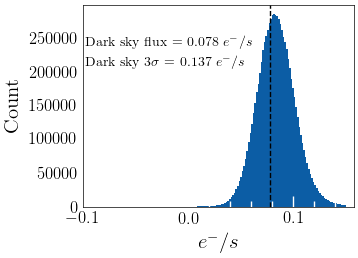

In [21]:
f = 3
detector = 1
data = fits.open(flc_paths[f])
exptime = data[0].header["EXPTIME"]
temp = data[detector].data.ravel() / exptime
dark_sky = temp[(temp > 0) & (temp < .15)]

plt.hist(dark_sky, bins=100)
plt.annotate(r"Dark sky flux = %.3f $e^{-}/s$" % np.mean(dark_sky_modes), xy=(0.01, 0.8), xycoords="axes fraction")
plt.annotate(r"Dark sky $3\sigma$ = %.3f $e^{-}/s$" % np.mean(three_sigmas), xy=(0.01, 0.7), xycoords="axes fraction")
plt.xlim(-0.1)
plt.xlabel(r"$e^{-}/s$")
plt.ylabel("Count")
plt.axvline(np.mean(dark_sky_modes), color="k", ls="--");

## Make a selection based on flux and pixels above $3\sigma$ using PAM corrected postage stamps

In [22]:
N = 5000
img_size = int(size.value)
good_crops = []
bad_crops = []

criteria = 2 # percentage of pixel with a flux above 3 sigma

for i, f in tqdm(enumerate(flc_paths)):
    for j, detector in enumerate([1, 4]):
        k = i * 2 + j
        data = fits.open(f)
        img = data[detector].data
        wcs = WCS(data[detector].header, data)
        pam = pamutils.pam_from_wcs(wcs) # pixel area map read from distortion table coefficients in fits file
        exptime = data[0].header["EXPTIME"]
        dark_sky = dark_sky_modes[k] # use the measured (detector specific) dark sky flux measurement 
        three_sigma_rule = three_sigmas[k] # same for the 3 sigma rule
        crops = create_random_crops(img * pam / exptime - dark_sky, img_size , img_size, N) # correct flux with PAM here
        for c in crops:
            if ((c > three_sigma_rule).sum() / img_size**2 * 100) < criteria: 
                good_crops.append(c)
            else: 
                bad_crops.append(c)
print(f"{len(good_crops):d} good crops and {len(bad_crops):d} bad crops")

4it [00:04,  1.22s/it]

37622 good crops and 2378 bad crops


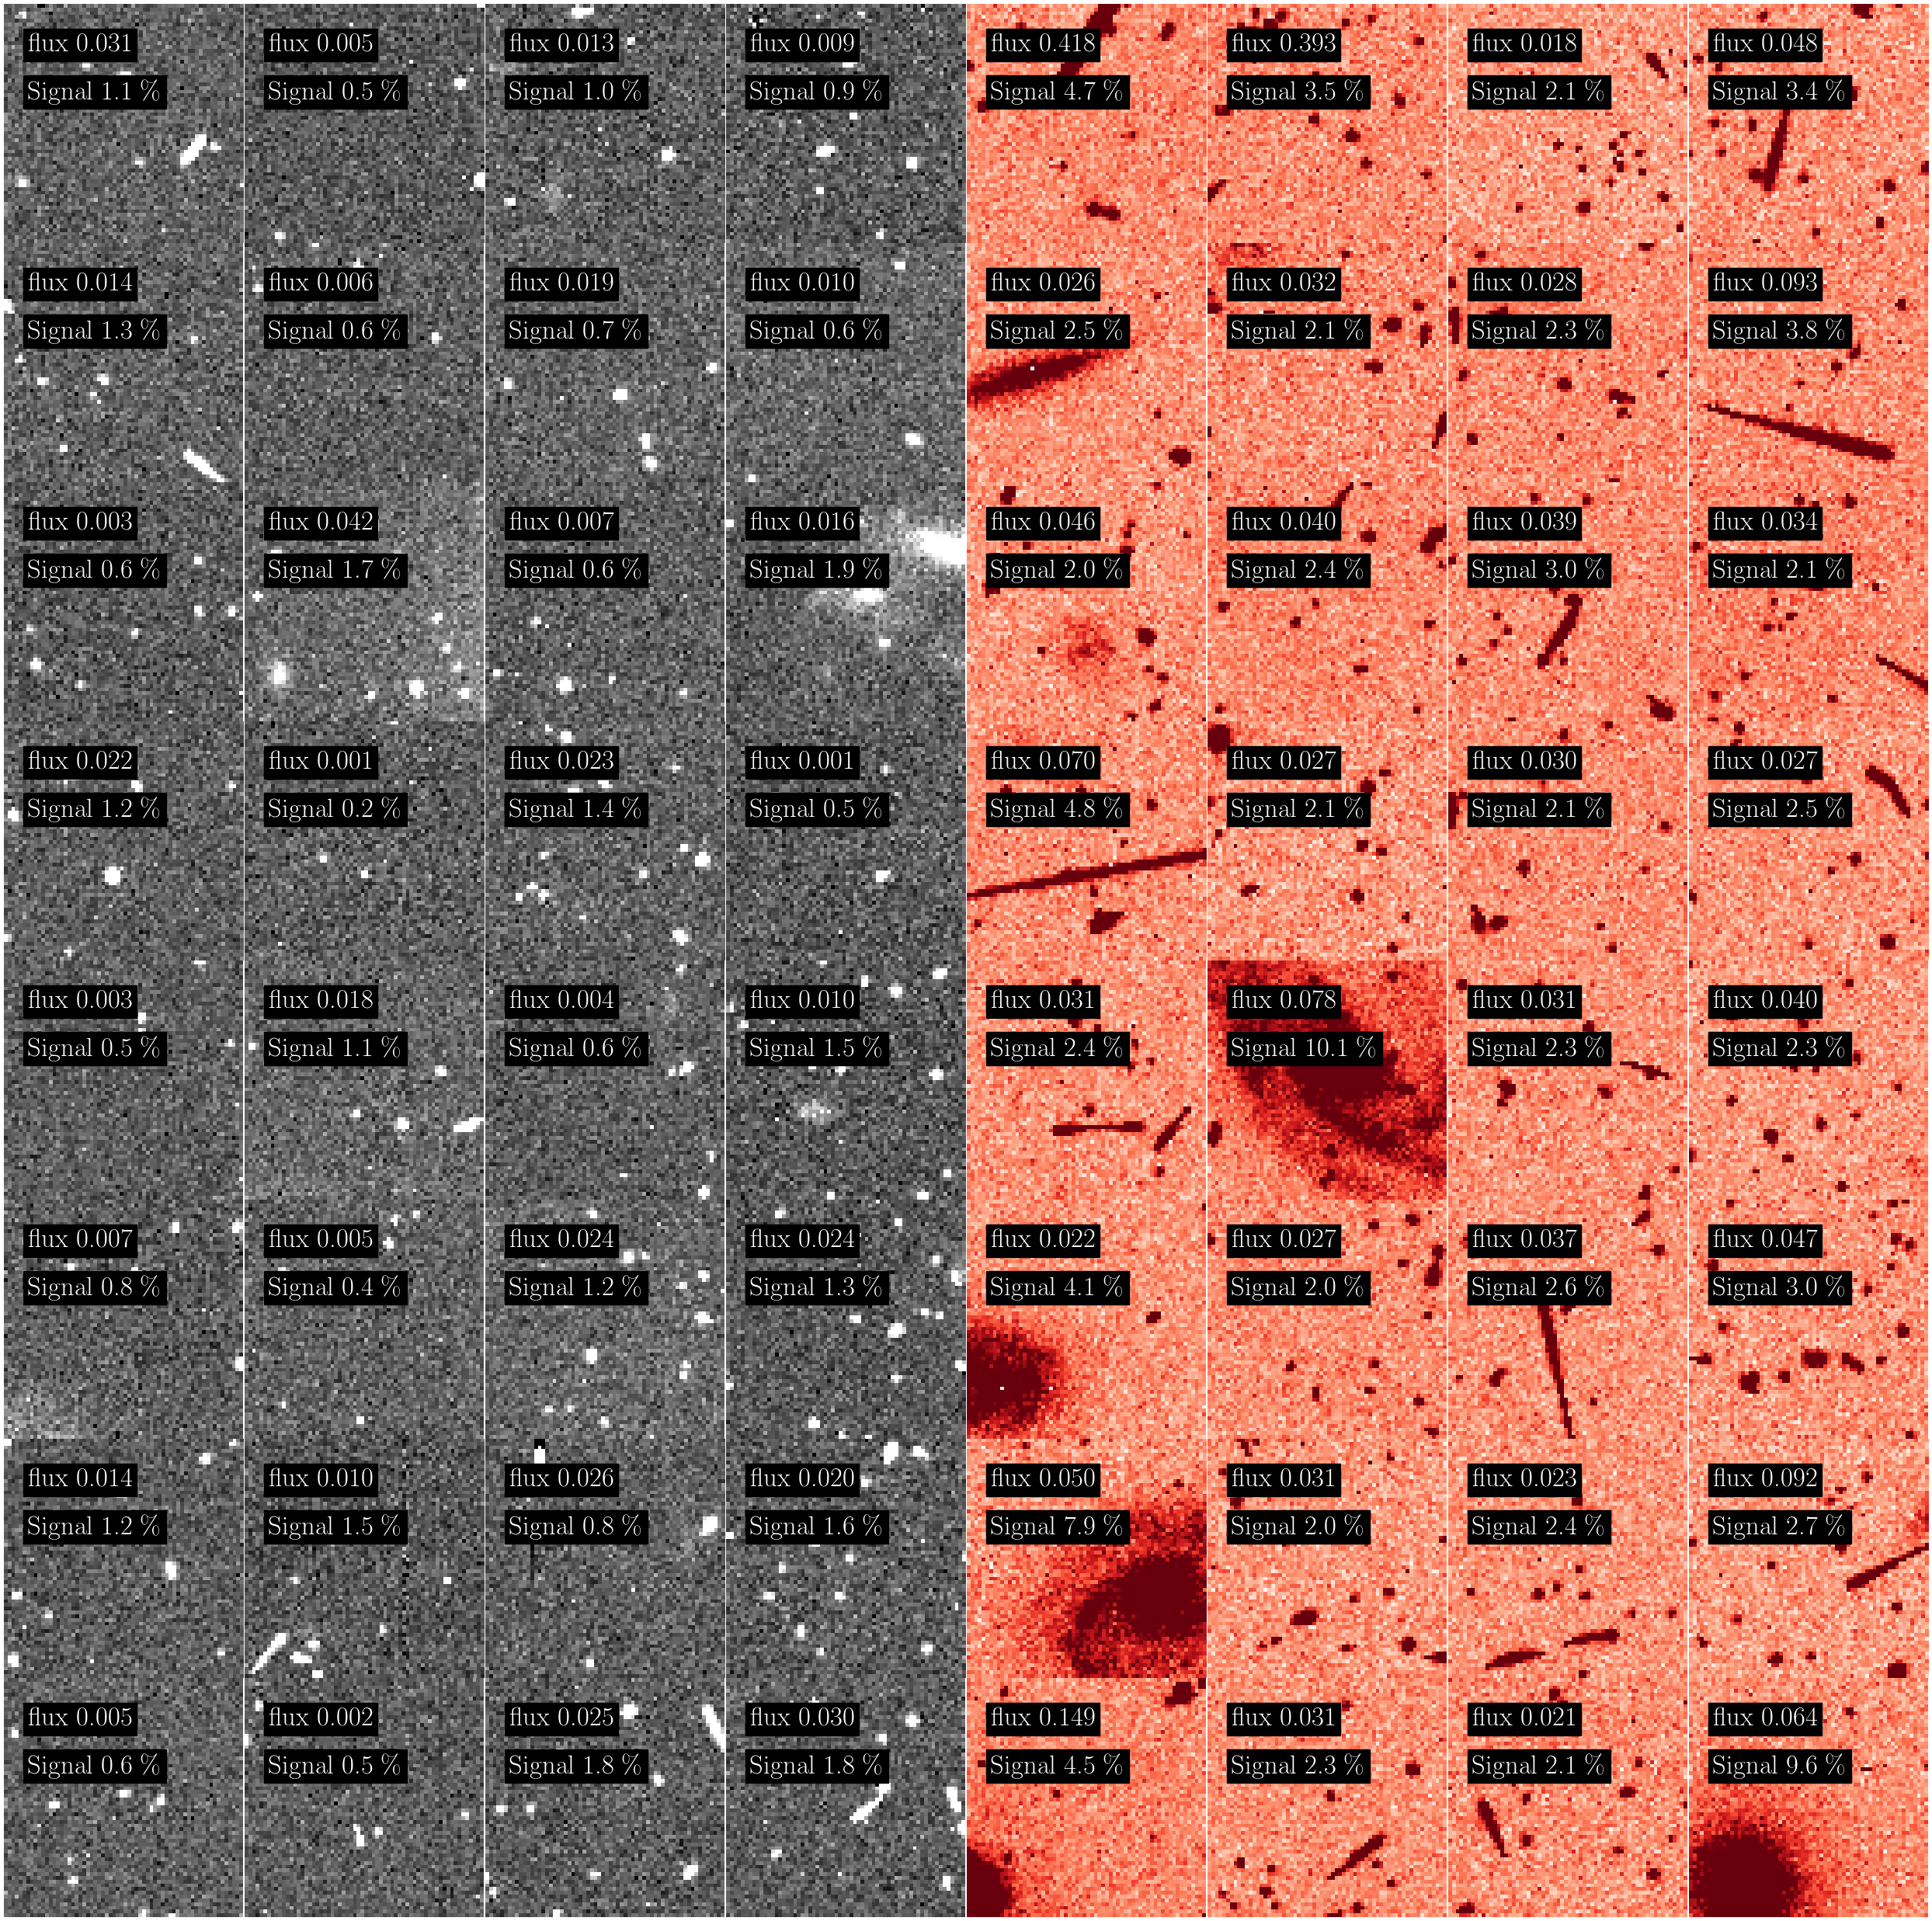

In [384]:
fig, axs = plt.subplots(8, 8, figsize=(32, 32))

# Take the average for estimating if the rule works well
three_sigma_rule = np.mean(three_sigmas)
for i in range(8):
    for j in range(4):
        k = np.random.randint(len(good_crops))
        axs[i, j].imshow(good_crops[k], cmap="gray", vmin=-0.06, vmax=0.1)
        axs[i, j].annotate(f"flux {good_crops[k].sum()/img_size**2:.3f}", xy=(0.1, 0.8), xycoords="axes fraction", color="w", fontsize=25, backgroundcolor="k")
        axs[i, j].annotate(fr"Signal {(good_crops[k] > three_sigma_rule).sum()/img_size**2 * 100:.1f} \%", xy=(0.1, 0.6), xycoords="axes fraction", color="w", fontsize=25, backgroundcolor="k")
        axs[i, j].axis("off")
        
    for j in range(4):
        k = np.random.randint(len(bad_crops))
        axs[i, 4+j].imshow(bad_crops[k], cmap="Reds", vmin=-0.06, vmax=0.1)
        axs[i, 4+j].annotate(f"flux {bad_crops[k].sum()/img_size**2:.3f}", xy=(0.1, 0.8), xycoords="axes fraction", color="w", fontsize=25, backgroundcolor="k")
        axs[i, 4+j].annotate(fr"Signal {(bad_crops[k] > three_sigma_rule).sum()/img_size**2 * 100:.1f} \%", xy=(0.1, 0.6), xycoords="axes fraction", color="w", fontsize=25, backgroundcolor="k")
        axs[i, 4+j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

# Save the datasets

In [24]:
# save the noise dataset for training
np.save("../data/connor_targets_flat_fields_noise_cutouts.npy", np.stack(good_crops, axis=0))

In [41]:
hdu_p = fits.PrimaryHDU(header=drz_data[0].header)
drz1 = fits.ImageHDU(cutout1.data, name="drz", header=cutout1.wcs.to_header())
flcs1 = []
for i, c in enumerate(cutouts1_flc):
    raw_data = fits.open(flc_paths[i]) # Load the Distortion paper (crucial since we need the WCS to get half pixel shift, and they need SIP to make sense)
    distortion_papers = raw_data[7:]
    # Cutout 1 is on WFC2, or (sci, 2), so index of dark sky is 2*i + 1
    dark_sky = dark_sky_modes[2*i+1] # use the measured (detector specific) dark sky flux measurement 
    pam = pamutils.pam_from_wcs(c.wcs) # pixel area map read from distortion table coefficients in fits file
    exptime = fits.open(flc_paths[i])[0].header["EXPTIME"]
    header = headers1_flc[i]
    wcs_hdr = c.wcs.to_header()
    # Make sure to tell WCS we are using SIP distortions, otherwise it complains endlessly
    wcs_hdr["CTYPE1"] = 'RA---TAN-SIP'
    wcs_hdr["CTYPE2"] = 'DEC--TAN-SIP'
    header.update(wcs_hdr)
    flcs1.append(fits.ImageHDU(c.data * pam / exptime - dark_sky, name="flc", header=header))
hdul1 = fits.HDUList([hdu_p, drz1] + flcs1 + distortion_papers)

drz2 = fits.ImageHDU(cutout2.data, name="drz", header=cutout2.wcs.to_header())
flcs2 = []
for i, c in enumerate(cutouts2_flc):
    raw_data = fits.open(flc_paths[i])
    distortion_papers = raw_data[7:]
    # Cutout 3 is on WFC1, or (sci, 1), so index of dark sky is 2*i + 0
    dark_sky = dark_sky_modes[2*i] # use the measured (detector specific) dark sky flux measurement 
    pam = pamutils.pam_from_wcs(c.wcs) # pixel area map read from distortion table coefficients in fits file
    exptime = fits.open(flc_paths[i])[0].header["EXPTIME"]
    header = headers2_flc[i]
    wcs_hdr = c.wcs.to_header()
    # Make sure to tell WCS we are using SIP distortions, otherwise it complains endlessly
    wcs_hdr["CTYPE1"] = 'RA---TAN-SIP'
    wcs_hdr["CTYPE2"] = 'DEC--TAN-SIP'
    header.update(wcs_hdr)
    flcs2.append(fits.ImageHDU(c.data * pam / exptime - dark_sky, name="flc", header=header))
hdul2 = fits.HDUList([hdu_p, drz2] + flcs2 + distortion_papers)

drz3 = fits.ImageHDU(cutout3.data, name="drz", header=cutout3.wcs.to_header())
flcs3 = []
for i, c in enumerate(cutouts3_flc):
    raw_data = fits.open(flc_paths[i]) # Load the Distortion paper (crucial since we need the WCS to get half pixel shift, and they need SIP to make sense)
    distortion_papers = raw_data[7:]
    # Cutout 3 is on WFC1, or (sci, 1), so index of dark sky is 2*i + 0
    dark_sky = dark_sky_modes[2*i] # use the measured (detector specific) dark sky flux measurement 
    pam = pamutils.pam_from_wcs(c.wcs) # pixel area map read from distortion table coefficients in fits file
    exptime = fits.open(flc_paths[i])[0].header["EXPTIME"]
    header = headers3_flc[i]
    wcs_hdr = c.wcs.to_header()
    # Make sure to tell WCS we are using SIP distortions, otherwise it complains endlessly
    wcs_hdr["CTYPE1"] = 'RA---TAN-SIP'
    wcs_hdr["CTYPE2"] = 'DEC--TAN-SIP'
    header.update(wcs_hdr)
    flcs3.append(fits.ImageHDU(c.data * pam / exptime - dark_sky, name="flc", header=header))
hdul3 = fits.HDUList([hdu_p, drz3] + flcs3 + distortion_papers)


hdul1.writeto("../data/connors_target1.fits", overwrite=True)
hdul2.writeto("../data/connors_target2.fits", overwrite=True)
hdul3.writeto("../data/connors_target3.fits", overwrite=True)

# Some checks with coordinate systems when loading it

In [42]:
data = fits.open("../data/connors_target1.fits")
for i in range(4):
    loaded_wcs = WCS(data[2 + i].header, data) # Make note of how we load WCS in general when distortion papers are present
    wcs = cutouts1_flc[i].wcs
    loaded_ref = loaded_wcs.world_to_pixel(coord1)
    print(loaded_ref)
    ref = wcs.world_to_pixel(coord1)
    print(ref) # they better agree 2 by two or our forward model breaks

(array(31.35547474), array(31.25711841))
(array(31.35547474), array(31.25711841))
(array(31.69728441), array(31.38286784))
(array(31.69728441), array(31.38286784))
(array(31.85290198), array(31.45440332))
(array(31.85290198), array(31.45440332))
(array(31.74331057), array(31.02573204))
(array(31.74331057), array(31.02573204))


In [43]:
data = fits.open("../data/connors_target2.fits")
for i in range(4):
    loaded_wcs = WCS(data[2 + i].header, data) # Make note of how we load WCS in general when distortion papers are present
    wcs = cutouts2_flc[i].wcs
    loaded_ref = loaded_wcs.world_to_pixel(coord2)
    print(loaded_ref)
    ref = wcs.world_to_pixel(coord2)
    print(ref) # they better agree 2 by two or our forward model breaks

(array(31.45096733), array(31.3140531))
(array(31.45096733), array(31.3140531))
(array(31.58184951), array(31.76020481))
(array(31.58184951), array(31.76020481))
(array(31.18540075), array(31.78505797))
(array(31.18540075), array(31.78505797))
(array(31.74859463), array(31.85391053))
(array(31.74859463), array(31.85391053))


In [44]:
data = fits.open("../data/connors_target3.fits")
for i in range(4):
    loaded_wcs = WCS(data[2 + i].header, data) # Make note of how we load WCS in general when distortion papers are present
    wcs = cutouts3_flc[i].wcs
    loaded_ref = loaded_wcs.world_to_pixel(coord3)
    print(loaded_ref)
    ref = wcs.world_to_pixel(coord3)
    print(ref) # they better agree 2 by two or our forward model breaks

(array(31.35937805), array(31.88656138))
(array(31.35937805), array(31.88656138))
(array(31.04596771), array(31.58105707))
(array(31.04596771), array(31.58105707))
(array(31.88334155), array(31.96786671))
(array(31.88334155), array(31.96786671))
(array(31.02058435), array(31.24068793))
(array(31.02058435), array(31.24068793))


In [78]:
wcs.to_header()

WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                869.0 / Pixel coordinate of reference point            
CRPIX2  =               -525.0 / Pixel coordinate of reference point            
PC1_1   =  2.8096734880276E-06 / Coordinate transformation matrix element       
PC1_2   =  1.3845371068287E-05 / Coordinate transformation matrix element       
PC2_1   =  1.3558115622638E-05 / Coordinate transformation matrix element       
PC2_2   = -1.8870832006588E-06 / Coordinate transformation matrix element       
CDELT1  =                  1.0 / [deg] Coordinate increment at reference point  
CDELT2  =                  1.0 / [deg] Coordinate increment at reference point  
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'                / Units of coordinate increment and value        
CTYPE1  = 'RA---TAN'           / TAN (gnomonic) projection + SIP distortions    
CTYPE2  = 'DEC--TAN'        

In [191]:
det = np.linalg.det(wcs.pixel_scale_matrix)

In [192]:
pc = wcs.pixel_scale_matrix

In [193]:
pc

array([[ 2.80967349e-06,  1.38453711e-05],
       [ 1.35581156e-05, -1.88708320e-06]])

In [199]:
R = -pc / abs(np.linalg.det(pc))**(1/2)
R

array([[-0.20223465, -0.99656197],
       [-0.9758859 ,  0.13582845]])

In [197]:
R @ R.T

array([[1.03403462, 0.06199647],
       [0.06199647, 0.97080266]])

In [183]:
_R = np.array([[0, 1], [1, 0]])

In [184]:
_pc = _R @ pc
_pc

array([[ 1.35581156e-05, -1.88708320e-06],
       [ 2.80967349e-06,  1.38453711e-05]])

In [189]:
R = _pc #/ np.linalg.det(_pc)**(1/2)
R

array([[ 1.35581156e-05, -1.88708320e-06],
       [ 2.80967349e-06,  1.38453711e-05]])

In [186]:
R @ R.T

array([[0.97080266, 0.06199647],
       [0.06199647, 1.03403462]])

In [75]:
pc.T @ pc / det

array([[-0.99325215, -0.06898629],
       [-0.06898629, -1.01158513]])

In [66]:
wcs.wcs.cd

array([[ 2.80967349e-06,  1.38453711e-05],
       [ 1.35581156e-05, -1.88708320e-06]])

In [67]:
wcs.wcs.cdelt

/tmp/ipykernel_22385/1917255867.py:1: RuntimeWarning: cdelt will be ignored since cd is present
  wcs.wcs.cdelt


array([1., 1.])

In [68]:
wcs.to_header()

WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                869.0 / Pixel coordinate of reference point            
CRPIX2  =               -525.0 / Pixel coordinate of reference point            
PC1_1   =  2.8096734880276E-06 / Coordinate transformation matrix element       
PC1_2   =  1.3845371068287E-05 / Coordinate transformation matrix element       
PC2_1   =  1.3558115622638E-05 / Coordinate transformation matrix element       
PC2_2   = -1.8870832006588E-06 / Coordinate transformation matrix element       
CDELT1  =                  1.0 / [deg] Coordinate increment at reference point  
CDELT2  =                  1.0 / [deg] Coordinate increment at reference point  
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'                / Units of coordinate increment and value        
CTYPE1  = 'RA---TAN'           / TAN (gnomonic) projection + SIP distortions    
CTYPE2  = 'DEC--TAN'        